### Project BackGround  

Brain tumors are serious neurological conditions that require early and accurate diagnosis for effective treatment. Magnetic Resonance Imaging (MRI) is widely used for detecting brain abnormalities; however, manual interpretation of MRI scans is time-consuming and may lead to diagnostic errors due to the complexity of medical images. Traditional image processing and machine learning methods often struggle to extract meaningful features from such data.

Convolutional Neural Networks (CNNs) have demonstrated strong performance in medical image analysis by automatically learning features from raw MRI images. This project aims to develop an enhanced CNN-based model for automatic brain tumor detection from MRI images to improve diagnostic accuracy and support healthcare professionals in timely decision-making.

In [97]:
# import libraries

from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.applications import VGG16
from tensorflow.keras.layers import Input
from tensorflow.keras.layers import Dense
from tensorflow.keras.layers import AveragePooling2D
from tensorflow.keras.layers import Dropout
from tensorflow.keras.layers import Flatten
from tensorflow.keras.models import Model
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.utils import to_categorical
from tensorflow.keras.layers import *
from tensorflow.keras.models import Model
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau, ModelCheckpoint
import tensorflow as tf





from sklearn.preprocessing import LabelBinarizer
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report, confusion_matrix

from PIL import Image
import matplotlib.pyplot as plt
import glob

from imutils import paths
import numpy as np
import matplotlib.pyplot as plt
import argparse
import os
import cv2
from collections import Counter

SEED = 42
os.environ['TF_DETERMINISTIC_OPS'] = '1'
np.random.seed(SEED)
tf.random.set_seed(SEED)
random.seed(SEED)
os.environ['PYTHONHASHSEED'] = str(SEED)

In [98]:
#load images from directory file
path = r"C:\Users\Stanley Lisuvirizwa\Desktop\Tumor_project\brain_tumor_dataset"
print(os.listdir(path))

image_paths = sorted(paths.list_images(path))
print(len(image_paths))

['no', 'yes']
253


#### explore class imbalance

In [75]:
labels = [img_path.split(os.path.sep)[-2] for img_path in image_paths]


In [76]:
label_counts = Counter(labels)
print(label_counts)

Counter({'yes': 155, 'no': 98})


Counter({'yes': 155, 'no': 98})


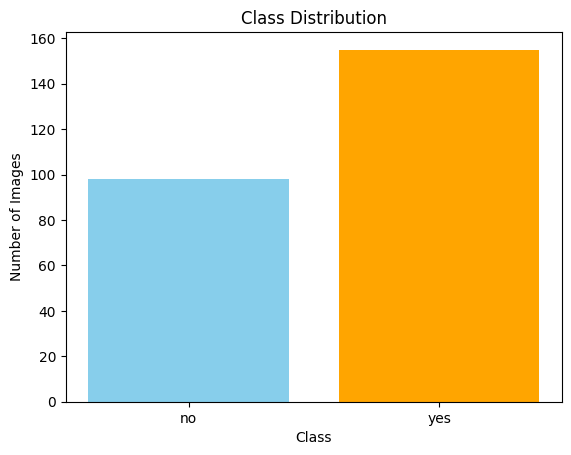

In [77]:
label_counts = Counter(labels)
print(label_counts)

plt.bar(label_counts.keys(), label_counts.values(), color=['skyblue', 'orange'])
plt.title("Class Distribution")
plt.xlabel("Class")
plt.ylabel("Number of Images")
plt.savefig("Class distribution")

plt.show()

- classes are imbalanced, Augmentation will assist in balancing

#### Visualize sample images from both classes

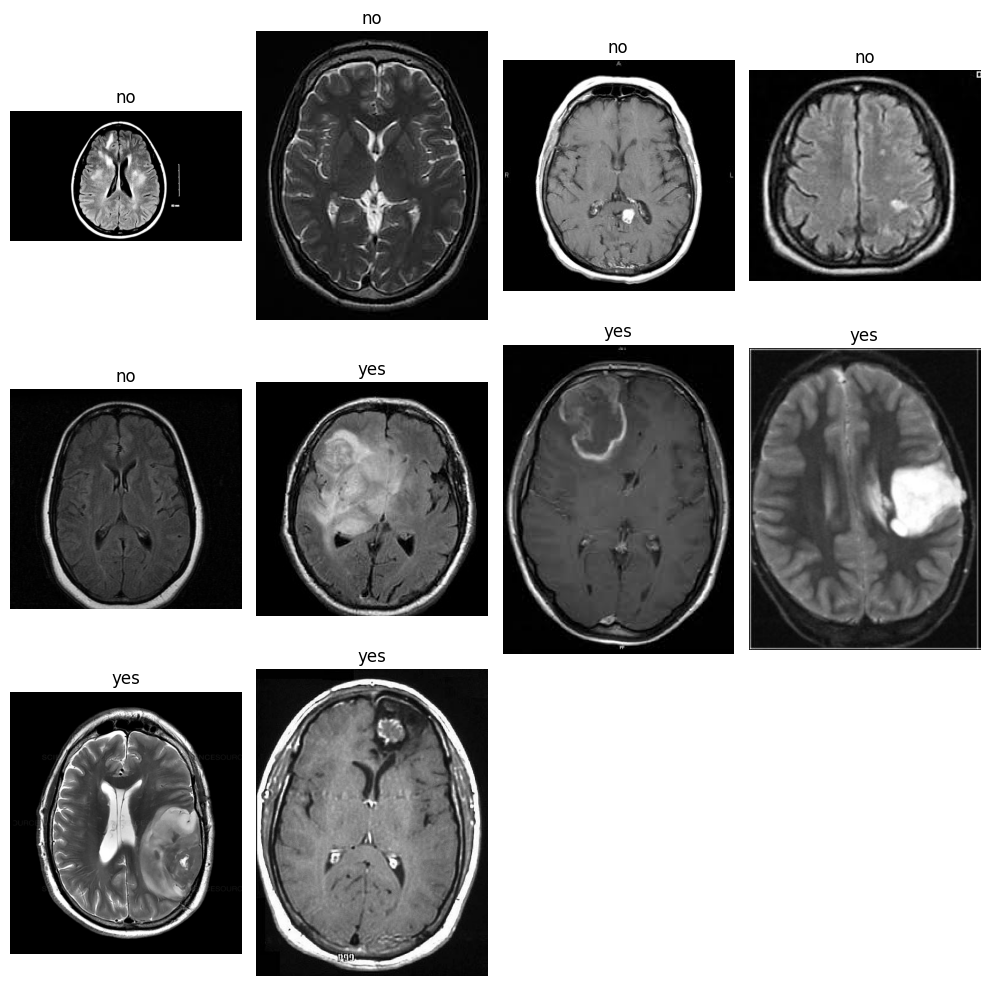

In [106]:
import random

class_dict = {}

for img_path in image_paths:
    label = img_path.split(os.path.sep)[-2]
    class_dict.setdefault(label, []).append(img_path)

samples = []
for label, paths_list in class_dict.items():
    sampled = random.sample(paths_list, min(5, len(paths_list)))
    samples.extend([(p, label) for p in sampled])

plt.figure(figsize=(10, 10))

for i, (img_path, label) in enumerate(samples):
    img = cv2.imread(img_path)
    img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
    
    plt.subplot(3, 4, i + 1)
    plt.imshow(img)
    plt.title(label)
    plt.axis("off")

plt.tight_layout()
plt.savefig("unprocessed_img_sample.png")
plt.show()

- Images have different sizes , there is need to eplore pixel size, width, hight. the resize to achieve equal image size
- there is need to adjust image angle through a 15 degree rotation

#### Analyze image sizes to verify any need of resizing images

In [28]:
widths = []
heights = []

for img_path in image_paths:
    img = cv2.imread(img_path)
    h, w = img.shape[:2]
    heights.append(h)
    widths.append(w)

print("Min Width:", min(widths), "Max Width:", max(widths))
print("Min Height:", min(heights), "Max Height:", max(heights))

Min Width: 150 Max Width: 1920
Min Height: 168 Max Height: 1427


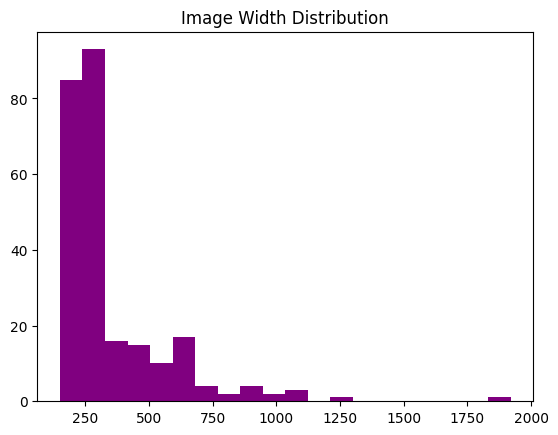

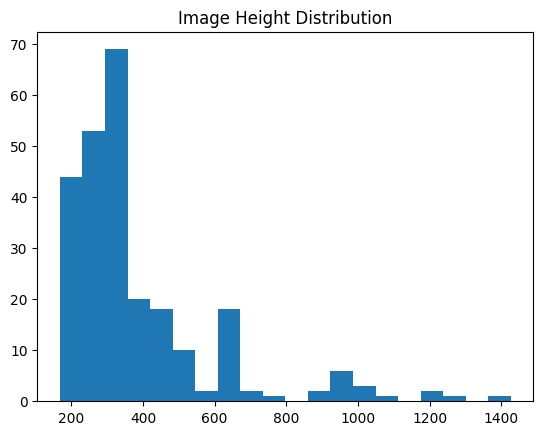

In [29]:
#plot image size 

plt.hist(widths, bins=20, color = ['purple'])
plt.title("Image Width Distribution")
plt.savefig("Width.png")
plt.show()

plt.hist(heights, bins=20)
plt.title("Image Height Distribution")
plt.savefig("Image  Height dist")
plt.show()

- From above there is evident variations in width and height, therefore we will readjust to equal width and height

#### Confirm image color channels (grayscal vs rgb)

In [78]:
gray_count = 0
rgb_count = 0

for img_path in image_paths[:100]:  # sample for speed
    img = cv2.imread(img_path)
    if len(img.shape) == 2:
        gray_count += 1
    else:
        rgb_count += 1

print("Grayscale:", gray_count)
print("RGB:", rgb_count)

Grayscale: 0
RGB: 100


### Check for existence of  any corupt images; incase of any the they will need to be droped

In [31]:
corrupt = []

for img_path in image_paths:
    img = cv2.imread(img_path)
    if img is None:
        corrupt.append(img_path)

print("Corrupt images:", len(corrupt))

Corrupt images: 0


#### Check pixel intensity

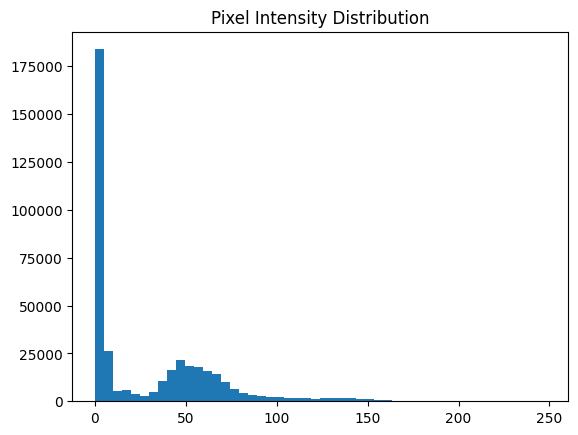

In [32]:
sample_img = cv2.imread(image_paths[0], cv2.IMREAD_GRAYSCALE)

plt.hist(sample_img.ravel(), bins=50)
plt.title("Pixel Intensity Distribution")
plt.savefig("pixel intensity.png")
plt.show()

- Variation in tussue density is evident from above image posibbly on tumor vs non tumor regions
- pixel values are spread unevenly which might call for augmentation
- contrast inconsistency where some images are brighter than others this will be adressed on preprocessing

### Data Preprocessing

Data preprocessing will ivolve steps like:

1. resizing of images to achieve consistency in the dataset in terms of shape and size for faster model training and reduction of mismatch errors in the model.
2. Intensity Normalization - since MRI images have different brightness and contrast and with variation in pixel intensity, normalization will help to scale pixel values making making model focus on tumor features, improves convergence.
3. Image cropping  - Remove any irrelevant non-brain tissues like sculp , eyes,or background which will improve localization accuracy , improve false positive cases.
4. Data Augmantation - since MRI data set is small and the images may vary in shape,orientation and size, augmantation will help increasing image size and create variations in existing images, this will prevent overfitting, make model more robust to rotation and scale changes.

In [108]:
def preprocess_image(img_path, size=(224, 224)):
    # Load image
    img = cv2.imread(img_path)
    
    # Convert to grayscale (for mask creation only)
    gray = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY)
    
    # Blur to reduce noise
    blur = cv2.GaussianBlur(gray, (5, 5), 0)
    
    # Threshold to separate brain from background
    _, thresh = cv2.threshold(blur, 45, 255, cv2.THRESH_BINARY)
    
    # Morphological operations (clean mask)
    kernel = np.ones((3, 3), np.uint8)
    thresh = cv2.erode(thresh, kernel, iterations=2)
    thresh = cv2.dilate(thresh, kernel, iterations=2)
    
    # Find contours
    contours, _ = cv2.findContours(thresh.copy(), cv2.RETR_EXTERNAL, cv2.CHAIN_APPROX_SIMPLE)
    
    if len(contours) > 0:
        # Get largest contour (brain)
        c = max(contours, key=cv2.contourArea)
        
        # Create empty mask
        mask = np.zeros(gray.shape, dtype="uint8")
        
        # Draw filled contour (brain region)
        cv2.drawContours(mask, [c], -1, 255, -1)
        
        # Apply mask
        brain = cv2.bitwise_and(img, img, mask=mask)
        
        # Crop to bounding box
        x, y, w, h = cv2.boundingRect(c)
        brain = brain[y:y+h, x:x+w]
    else:
        brain = img  # fallback
    
    # Resize
    brain = cv2.resize(brain, size)
    
    # Normalize
    brain = brain / 255.0
    
    return brain

In [109]:
data = []
labels_list = []

for img_path in image_paths:
    try:
        processed_img = preprocess_image(img_path)
        data.append(processed_img)
        
        label = img_path.split(os.path.sep)[-2]
        labels_list.append(label)
        
    except Exception as e:
        print(f"Error processing {img_path}: {e}")

In [110]:
#covert to arrays
X = np.array(data, dtype="float32")
y = np.array(labels_list)

print("Shape of X:", X.shape)
print("Shape of y:", y.shape)

Shape of X: (253, 224, 224, 3)
Shape of y: (253,)


#### Encode class lebels

In [111]:

from sklearn.preprocessing import LabelEncoder
from tensorflow.keras.utils import to_categorical

le = LabelEncoder()
y_encoded = le.fit_transform(y)

y_categorical = to_categorical(y_encoded)  

#### visualize sample of preprocessed images

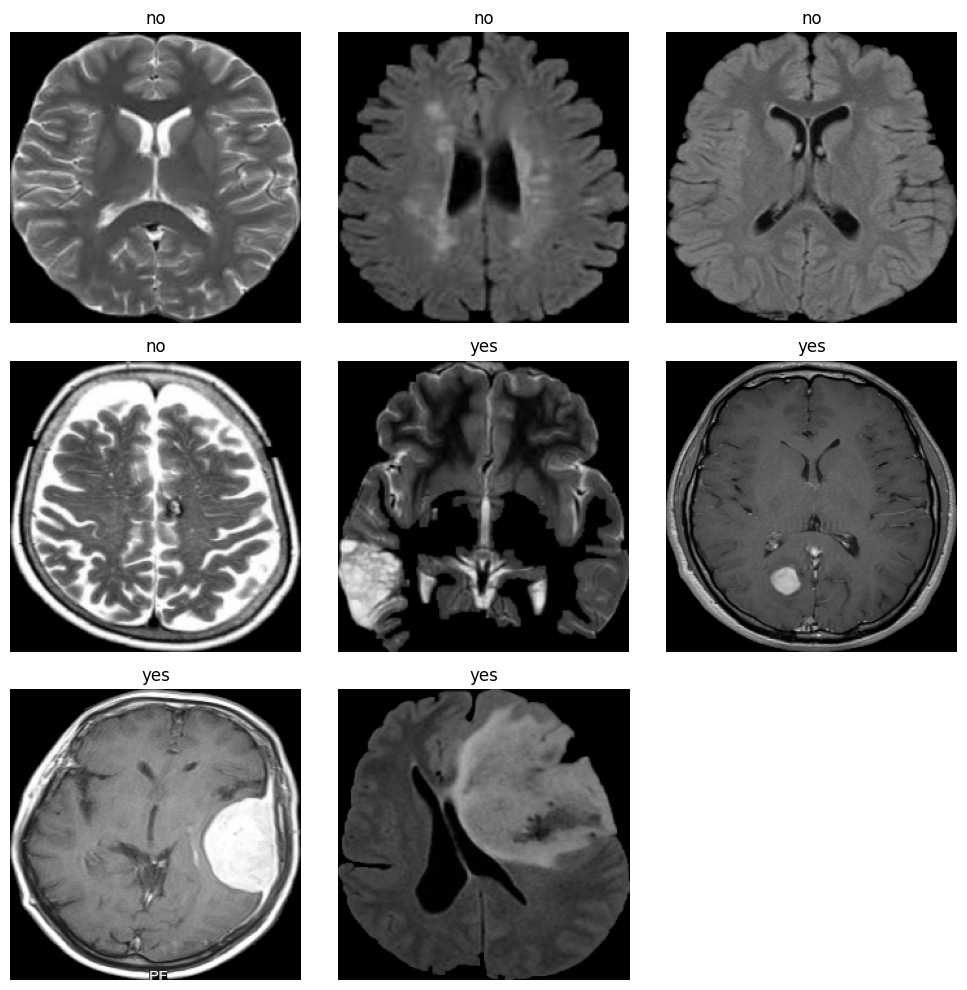

In [112]:


plt.figure(figsize=(10, 10))

count = 0
classes = le.classes_

for class_idx, class_name in enumerate(classes):
    
    idxs = np.where(y_encoded == class_idx)[0]
    
    sample_idxs = np.random.choice(idxs, min(4, len(idxs)), replace=False)
    
    for i in sample_idxs:
        count += 1
        plt.subplot(3, 3, count)
        plt.imshow(X[i])
        plt.title(class_name)
        plt.axis("off")

plt.tight_layout()
plt.savefig("Preporcessed_imagesamples.png")
plt.show()

### Split Dataset

In [99]:
X_train, X_temp, y_train, y_temp, y_train_enc, y_temp_enc = train_test_split(
    X, y_categorical, y_encoded,
    test_size=0.3,          
    stratify=y_encoded,
    random_state=42
)

In [100]:
X_val, X_test, y_val, y_test, y_val_enc, y_test_enc = train_test_split(
    X_temp, y_temp, y_temp_enc,
    test_size=0.5,        
    stratify=y_temp_enc,
    random_state=42
)

In [81]:
print(X_train.shape, y_val.shape, y_test.shape, y_train.shape, y_val.shape,y_test.shape)

(177, 224, 224, 3) (38, 2) (38, 2) (177, 2) (38, 2) (38, 2)


### Augmantation
 - Augmantation was done to help resolve the issue of class imbalance, which will help in increasing diversity of the dataset for adeqeate model training
- images were rotated slighly at -+15, empty pixels created by rotation were filled using nearest values, in each epoch  the model can have slightly different versions of the same image.
- contrast adjustment, flip images , zoom in /out was also considered on the augmentation pipeline


In [89]:
# Define augmentation pipeline
train_aug = ImageDataGenerator(
    rotation_range=10,
    fill_mode='nearest'
)
val_aug = ImageDataGenerator()    # no augmentation for val / test


## 8.  Model Architecture — VGG16 Transfer Learning

### Why Transfer Learning?
Building a CNN from scratch on 253 images would almost certainly overfit.  
**VGG16** (pre-trained on ImageNet — 1.2M images, 1000 classes) provides:
- Rich low- to high-level feature extractors (edges → shapes → textures → objects)
- Stable weight initialisation
- Proven performance on medical imaging tasks

### Architecture Diagram

┌──────────────────────────────────────────┐
│        VGG16 Feature Extractor           │
│  Pretrained on ImageNet (Frozen Layers)  │
│  Conv + ReLU + MaxPooling Operations     │
└──────────────┬───────────────────────────┘
               │
               ▼
┌──────────────────────────────┐
│       Feature Maps           │
│ Learned tumor-related traits │
└──────────────┬───────────────┘
               │
               ▼
┌──────────────────────────────┐
│   AveragePooling2D (4 × 4)   │
│ Reduces spatial dimensions   │
└──────────────┬───────────────┘
               │
               ▼
┌──────────────────────────────┐
│           Flatten            │
│ Converts 2D features → 1D    │
└──────────────┬───────────────┘
               │
               ▼
┌──────────────────────────────┐
│      Dense Layer (64)        │
│     ReLU Activation          │
└──────────────┬───────────────┘
               │
               ▼
┌──────────────────────────────┐
│     Batch Normalization      │
│ Stabilizes model learning    │
└──────────────┬───────────────┘
               │
               ▼
┌──────────────────────────────┐
│       Dropout (0.5)          │
│ Prevents overfitting         │
└──────────────┬───────────────┘
               │
               ▼
┌──────────────────────────────┐
│    Output Layer Dense(2)     │
│      Softmax Activation      │
└──────────────┬───────────────┘
               │
               ▼
┌──────────────────────────────┐
│        Prediction            │
│  [No Tumor | Tumor]          │
└──────────────────────────────┘
```


In [90]:
# Load pre-trained VGG16 backbone (without top classifier)
base_model = VGG16(
    weights      = 'imagenet',
    include_top  = False,
    input_tensor = Input(shape=(224, 224, 3))
)

#  Freeze all base layers (feature extraction only) 
for layer in base_model.layers:
    layer.trainable = False

# Add custom classification head 
x = base_model.output
x = AveragePooling2D(pool_size=(4, 4))(x)
x = Flatten(name="flatten")(x)
x = Dense(64, activation='relu')(x)
x = BatchNormalization()(x)
x = Dropout(0.5)(x)
output = Dense(2, activation='softmax', name='predictions')(x)

model = Model(inputs=base_model.input, outputs=output, name="BrainTumor_VGG16")

# Count trainable vs frozen parameters
total_params     = model.count_params()
trainable_params = sum([tf.size(w).numpy() for w in model.trainable_weights])
frozen_params    = total_params - trainable_params

print(f" Model parameter summary:")
print(f"  Total parameters      : {total_params:>12,}")
print(f"   Trainable parameters  : {trainable_params:>12,}")
print(f"   Frozen (VGG16 base)   : {frozen_params:>12,}")
print(f"\n   Training {100*trainable_params/total_params:.1f}% of total parameters")

 Model parameter summary:
  Total parameters      :   14,747,906
   Trainable parameters  :       33,090
   Frozen (VGG16 base)   :   14,714,816

   Training 0.2% of total parameters


In [91]:
#view model summary

model.summary()



Model: "BrainTumor_VGG16"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_3 (InputLayer)      │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block1_conv1 (Conv2D)           │ (None, 224, 224, 64)   │         1,792 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block1_conv2 (Conv2D)           │ (None, 224, 224, 64)   │        36,928 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block1_pool (MaxPooling2D)      │ (None, 112, 112, 64)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block2_conv1 (Conv2D)           │ (None, 112, 112, 128)  │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block2_conv2 (Conv2D)           │ (None, 112, 112, 128)  │       147,584 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block2_pool (MaxPooling2D)      │ (None, 56, 56, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block3_conv1 (Conv2D)           │ (None, 56, 56, 256)    │       295,168 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block3_conv2 (Conv2D)           │ (None, 56, 56, 256)    │       590,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block3_conv3 (Conv2D)           │ (None, 56, 56, 256)    │       590,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block3_pool (MaxPooling2D)      │ (None, 28, 28, 256)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block4_conv1 (Conv2D)           │ (None, 28, 28, 512)    │     1,180,160 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block4_conv2 (Conv2D)           │ (None, 28, 28, 512)    │     2,359,808 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block4_conv3 (Conv2D)           │ (None, 28, 28, 512)    │     2,359,808 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block4_pool (MaxPooling2D)      │ (None, 14, 14, 512)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block5_conv1 (Conv2D)           │ (None, 14, 14, 512)    │     2,359,808 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block5_conv2 (Conv2D)           │ (None, 14, 14, 512)    │     2,359,808 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block5_conv3 (Conv2D)           │ (None, 14, 14, 512)    │     2,359,808 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block5_pool (MaxPooling2D)      │ (None, 7, 7, 512)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ average_pooling2d_3             │ (None, 1, 1, 512)      │             0 │
│ (AveragePooling2D)              │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 512)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 64)             │        32,832 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_3           │ (None, 64)             │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_3 (Dropout)             │ (None, 64)             │             

 Total params: 14,747,906 (56.26 MB)

 Trainable params: 33,090 (129.26 KB)

 Non-trainable params: 14,714,816 (56.13 MB)

### Model Training and callbacks
- call backs were included in the model training stage to help in adjusting learning rate, earlystoping and saving the model

In [92]:
# Hyper-parameters
BATCH_SIZE     = 8
EPOCHS         = 25
LEARNING_RATE  = 1e-4
MODEL_SAVE_PATH = "best_brain_tumor_model.h5"

# Compile
model.compile(
    optimizer = Adam(learning_rate=LEARNING_RATE),
    loss      = 'binary_crossentropy',
    metrics   = ['accuracy',
                 tf.keras.metrics.AUC(name='auc'),
                 tf.keras.metrics.Precision(name='precision'),
                 tf.keras.metrics.Recall(name='recall')]
)




In [93]:
# Callbacks 

callbacks = [
    EarlyStopping(monitor="val_auc", patience=7,
                  restore_best_weights=True, mode="max", verbose=1),
    ReduceLROnPlateau(monitor="val_loss", factor=0.5,
                      patience=4, min_lr=1e-7, verbose=1),
    ModelCheckpoint("best_model.keras", monitor="val_auc",
                    save_best_only=True, mode="max", verbose=1),
]

In [94]:

batch_size = BATCH_SIZE
train_steps = len(X_train) // batch_size
validation_steps = len(X_test) // batch_size
epochs = EPOCHS

In [114]:
#fit model
history = model.fit(
    train_aug.flow(X_train, y_train, batch_size=8, seed=SEED),
    validation_data = (X_val, y_val), 
    epochs          = 25,
    callbacks       = callbacks
)

Epoch 1/25
23/23 ━━━━━━━━━━━━━━━━━━━━ 0s 289ms/step - accuracy: 0.7102 - auc: 0.7757 - loss: 0.6483 - precision: 0.7102 - recall: 0.7102
Epoch 1: val_auc did not improve from 0.79501
23/23 ━━━━━━━━━━━━━━━━━━━━ 10s 389ms/step - accuracy: 0.7571 - auc: 0.7787 - loss: 0.6508 - precision: 0.7571 - recall: 0.7571 - val_accuracy: 0.6842 - val_auc: 0.7850 - val_loss: 0.6101 - val_precision: 0.6842 - val_recall: 0.6842 - learning_rate: 2.5000e-05
Epoch 2/25
23/23 ━━━━━━━━━━━━━━━━━━━━ 0s 287ms/step - accuracy: 0.6943 - auc: 0.7510 - loss: 0.6675 - precision: 0.6943 - recall: 0.6943
Epoch 2: val_auc did not improve from 0.79501
23/23 ━━━━━━━━━━━━━━━━━━━━ 8s 349ms/step - accuracy: 0.7232 - auc: 0.7731 - loss: 0.6396 - precision: 0.7232 - recall: 0.7232 - val_accuracy: 0.6316 - val_auc: 0.7836 - val_loss: 0.6059 - val_precision: 0.6316 - val_recall: 0.6316 - learning_rate: 2.5000e-05
Epoch 3/25
23/23 ━━━━━━━━━━━━━━━━━━━━ 0s 288ms/step - accuracy: 0.7364 - auc: 0.8059 - loss: 0.5874 - precision: 0.

### Fine tune the Model , with ununfrozen vgg16 layers

In [115]:
# Unfreeze the last 4 VGG16 layers
for layer in base_model.layers[-4:]:
    layer.trainable = True
model.compile(
    optimizer = Adam(learning_rate=1e-5),   # 10x lower than Phase 1
    loss      = "binary_crossentropy",
    metrics   = [
        "accuracy",
        tf.keras.metrics.AUC(name="auc"),
        tf.keras.metrics.Precision(name="precision"),
        tf.keras.metrics.Recall(name="recall"),
    ]
)



In [116]:
callbacks_p2 = [
    EarlyStopping(monitor="val_auc", patience=5,
                  restore_best_weights=True, mode="max", verbose=1),
    ModelCheckpoint("best_model_finetuned.keras", monitor="val_auc",
                    save_best_only=True, mode="max", verbose=1),
]

In [117]:


history_p2 = model.fit(
    train_aug.flow(X_train, y_train, batch_size=8, seed=SEED),
    validation_data = (X_val, y_val),
    epochs          = 15,
    callbacks       = callbacks_p2
)

Epoch 1/15
23/23 ━━━━━━━━━━━━━━━━━━━━ 0s 348ms/step - accuracy: 0.6957 - auc: 0.7230 - loss: 0.6784 - precision: 0.6957 - recall: 0.6957
Epoch 1: val_auc improved from None to 0.79259, saving model to best_model_finetuned.keras

Epoch 1: finished saving model to best_model_finetuned.keras
23/23 ━━━━━━━━━━━━━━━━━━━━ 12s 443ms/step - accuracy: 0.7175 - auc: 0.7547 - loss: 0.6407 - precision: 0.7175 - recall: 0.7175 - val_accuracy: 0.6579 - val_auc: 0.7926 - val_loss: 0.5965 - val_precision: 0.6579 - val_recall: 0.6579
Epoch 2/15
23/23 ━━━━━━━━━━━━━━━━━━━━ 0s 340ms/step - accuracy: 0.7872 - auc: 0.8430 - loss: 0.5693 - precision: 0.7872 - recall: 0.7872
Epoch 2: val_auc did not improve from 0.79259
23/23 ━━━━━━━━━━━━━━━━━━━━ 9s 400ms/step - accuracy: 0.7797 - auc: 0.8317 - loss: 0.5603 - precision: 0.7797 - recall: 0.7797 - val_accuracy: 0.5789 - val_auc: 0.7732 - val_loss: 0.5842 - val_precision: 0.5789 - val_recall: 0.5789
Epoch 3/15
23/23 ━━━━━━━━━━━━━━━━━━━━ 0s 344ms/step - accuracy: 

### Evaluate model on  test dataset

In [118]:
# 1. Scalar metrics
results = model.evaluate(X_test, y_test, verbose=0)

In [119]:
# 2. Predictions
y_prob = model.predict(X_test)
y_pred = np.argmax(y_prob, axis=1)
y_true = np.argmax(y_test,  axis=1)

1/2 ━━━━━━━━━━━━━━━━━━━━ 1s 1s/stepWARNING:tensorflow:6 out of the last 6 calls to <function TensorFlowTrainer.make_predict_function.<locals>.one_step_on_data_distributed at 0x00000202C4D86520> triggered tf.function retracing. Tracing is expensive and the excessive number of tracings could be due to (1) creating @tf.function repeatedly in a loop, (2) passing tensors with different shapes, (3) passing Python objects instead of tensors. For (1), please define your @tf.function outside of the loop. For (2), @tf.function has reduce_retracing=True option that can avoid unnecessary retracing. For (3), please refer to https://www.tensorflow.org/guide/function#controlling_retracing and https://www.tensorflow.org/api_docs/python/tf/function for  more details.
2/2 ━━━━━━━━━━━━━━━━━━━━ 2s 351ms/step


### Generate a confussion matrix and classification report to help identify any misclassifications

In [120]:
# 3. Confusion matrix
from sklearn.metrics import confusion_matrix, classification_report
print(confusion_matrix(y_true, y_pred))
print(classification_report(y_true, y_pred, target_names=["healthy", "tumor"]))

[[11  4]
 [ 1 22]]
              precision    recall  f1-score   support

     healthy       0.92      0.73      0.81        15
       tumor       0.85      0.96      0.90        23

    accuracy                           0.87        38
   macro avg       0.88      0.84      0.86        38
weighted avg       0.87      0.87      0.87        38



- 4 healthy cases are being missclasified as unlhealthy which might lead to further investigations and resource wastage ; since the goal is to accurately identify tumor cases only 1 image with tumor has been missclassified which is much 
- Model is good at catching tumors "better safe than sorry"

### Plot roc curve

In [54]:
# 4. ROC curve and optimal threshold
from sklearn.metrics import roc_curve, auc

In [121]:

fpr, tpr, thresholds = roc_curve(y_true, y_prob[:, 1])
roc_auc = auc(fpr, tpr)

In [122]:
J           = tpr - fpr
opt_thresh  = thresholds[np.argmax(J)]
print(f"AUC-ROC          : {roc_auc:.4f}")
print(f"Optimal threshold: {opt_thresh:.4f}")

AUC-ROC          : 0.9507
Optimal threshold: 0.5896


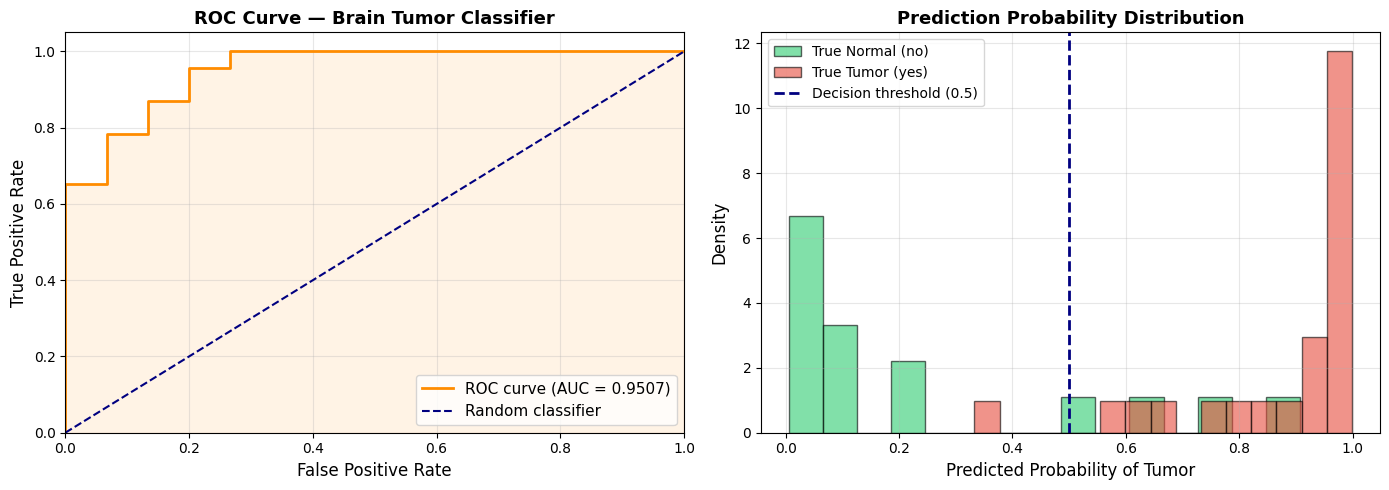

 AUC-ROC: 0.9507


In [123]:


fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# ROC curve
axes[0].plot(fpr, tpr, color='darkorange', lw=2, label=f'ROC curve (AUC = {roc_auc:.4f})')
axes[0].plot([0, 1], [0, 1], color='navy', lw=1.5, linestyle='--', label='Random classifier')
axes[0].fill_between(fpr, tpr, alpha=0.1, color='darkorange')
axes[0].set_xlim([0.0, 1.0])
axes[0].set_ylim([0.0, 1.05])
axes[0].set_xlabel('False Positive Rate', fontsize=12)
axes[0].set_ylabel('True Positive Rate', fontsize=12)
axes[0].set_title('ROC Curve — Brain Tumor Classifier', fontsize=13, fontweight='bold')
axes[0].legend(loc='lower right', fontsize=11)
axes[0].grid(True, alpha=0.3)

# Prediction probability distribution
axes[1].hist(y_prob[y_true==0, 1], bins=15, alpha=0.6, color='#2ECC71', 
             edgecolor='black', label='True Normal (no)', density=True)
axes[1].hist(y_prob[y_true==1, 1], bins=15, alpha=0.6, color='#E74C3C', 
             edgecolor='black', label='True Tumor (yes)', density=True)
axes[1].axvline(0.5, color='navy', linestyle='--', linewidth=2, label='Decision threshold (0.5)')
axes[1].set_xlabel('Predicted Probability of Tumor', fontsize=12)
axes[1].set_ylabel('Density', fontsize=12)
axes[1].set_title('Prediction Probability Distribution', fontsize=13, fontweight='bold')
axes[1].legend(fontsize=10)
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig('roc_curve.png', dpi=150, bbox_inches='tight')
plt.show()
print(f" AUC-ROC: {roc_auc:.4f}")


- From above RCO curve indicates the model records high AUC of 0.89, with high recall and less false positives which is a key metric in medical detection 
- There is clear probability separation

### Basic visualization of predicted samples

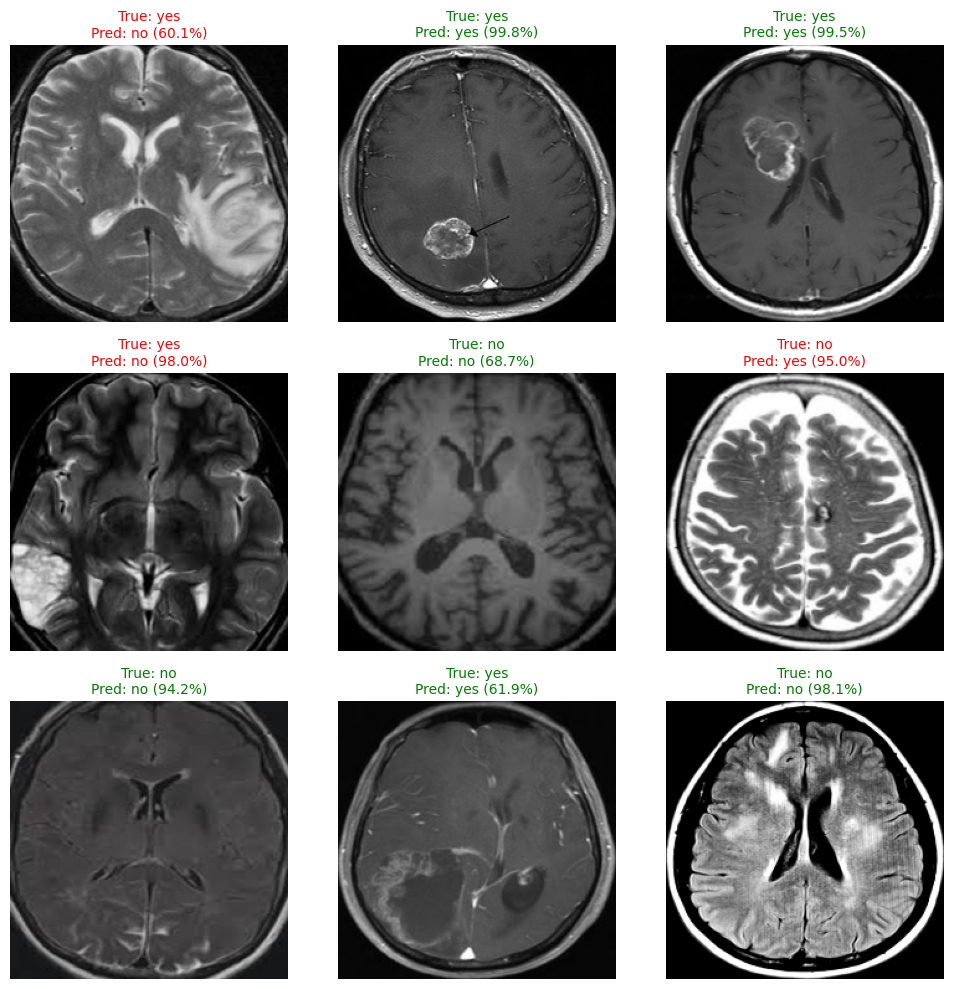

In [59]:
# class names (from your encoder)
class_names = le.classes_

# pick random samples
n_samples = 9
sample_idxs = random.sample(range(len(X_test)), n_samples)

plt.figure(figsize=(10, 10))

for i, idx in enumerate(sample_idxs):
    img = X_test[idx]
    
    true_label = class_names[y_true[idx]]
    pred_label = class_names[y_pred[idx]]
    confidence = y_prob[idx][y_pred[idx]]
    
    correct = (y_true[idx] == y_pred[idx])
    
    plt.subplot(3, 3, i + 1)
    plt.imshow(img)
    
    title_color = "green" if correct else "red"
    plt.title(
        f"True: {true_label}\nPred: {pred_label} ({confidence:.1%})",
        color=title_color,
        fontsize=10
    )
    
    plt.axis("off")

plt.tight_layout()
plt.show()

-  model is predicting tumor images well with high confidence in prediction; can be good for screening since it doesnt miss out on tumor images

##  Grad-CAM Explainability

**Gradient-weighted Class Activation Maps (Grad-CAM)** 
- highlight the regions of an MRI scan that most influenced the model's prediction on false and true positives, providing transparency and clinical interpretability.

In [2]:
def make_gradcam_heatmap(img_array, model, last_conv_layer_name="block5_conv3", pred_index=None):
    """
    Generate a Grad-CAM heatmap for the given image.

    Args:
        img_array         : (1, H, W, 3) normalised image
        model             : trained Keras model
        last_conv_layer_name: name of the last convolutional layer
        pred_index        : class index to explain (None → argmax)

    Returns:
        heatmap: (H, W) float array in [0, 1]
    """
    grad_model = Model(
        inputs  = model.inputs,
        outputs = [model.get_layer(last_conv_layer_name).output, model.output]
    )

    with tf.GradientTape() as tape:
        conv_outputs, predictions = grad_model(img_array)
        if pred_index is None:
            pred_index = tf.argmax(predictions[0])
        class_channel = predictions[:, pred_index]

    grads    = tape.gradient(class_channel, conv_outputs)
    pooled   = tf.reduce_mean(grads, axis=(0, 1, 2))
    conv_out = conv_outputs[0]

    heatmap = conv_out @ pooled[..., tf.newaxis]
    heatmap = tf.squeeze(heatmap)
    heatmap = tf.maximum(heatmap, 0) / (tf.math.reduce_max(heatmap) + 1e-8)
    return heatmap.numpy()


def overlay_gradcam(img, heatmap, alpha=0.4):
    """Overlay Grad-CAM heatmap on original image (RGB)."""
    heatmap_resized = cv2.resize(heatmap, (img.shape[1], img.shape[0]))
    heatmap_colored = np.uint8(255 * heatmap_resized)
    heatmap_colored = cv2.applyColorMap(heatmap_colored, cv2.COLORMAP_JET)
    heatmap_colored = cv2.cvtColor(heatmap_colored, cv2.COLOR_BGR2RGB)
    img_uint8       = np.uint8(255 * img)
    overlaid        = cv2.addWeighted(img_uint8, 1 - alpha, heatmap_colored, alpha, 0)
    return overlaid


print("Grad-CAM functions defined")


Grad-CAM functions defined


In [60]:
false_positive_idxs = np.where((y_true== 0) & (y_pred == 1))[0]

print(f"Number of False Positives: {len(false_positive_idxs)}")

Number of False Positives: 4


In [61]:
# True Positive: tumor correctly predicted
tp_idxs = np.where((y_true == 1) & (y_pred == 1))[0]

# False Positive: healthy predicted as tumor
fp_idxs = np.where((y_true == 0) & (y_pred == 1))[0]

print(f"TP: {len(tp_idxs)}, FP: {len(fp_idxs)}")

TP: 18, FP: 4


In [126]:
# Grad-CAM visualization function

def visualize_gradcam_group(indices, title, n_samples=4):
    class_names = le.classes_
    
    if len(indices) == 0:
        print(f"No samples for {title}")
        return
    
    sample_idxs = random.sample(list(indices), min(n_samples, len(indices)))
    
    fig, axes = plt.subplots(len(sample_idxs), 3, figsize=(14, 4 * len(sample_idxs)))
    
    if len(sample_idxs) == 1:
        axes = [axes]

    for row, idx in enumerate(sample_idxs):
        img = X_test[idx]

        true_idx = y_true[idx]
        pred_idx = y_pred[idx]

        true_label = class_names[true_idx]
        pred_label = class_names[pred_idx]
        confidence = y_prob[idx][pred_idx]

        # Grad-CAM
        heatmap = make_gradcam_heatmap(
            img[np.newaxis],
            model,
            last_conv_layer_name="block5_conv3",
            pred_index=pred_idx
        )

        overlay = overlay_gradcam(img, heatmap)

        # Plot
        axes[row][0].imshow(img)
        axes[row][0].set_title(f"Original\nTrue: {true_label}", fontweight='bold')

        axes[row][1].imshow(heatmap, cmap='jet')
        axes[row][1].set_title("Grad-CAM", fontweight='bold')

        axes[row][2].imshow(overlay)
        axes[row][2].set_title(
            f"Pred: {pred_label} ({confidence:.1%})",
            color='green' if true_idx == pred_idx else 'red',
            fontweight='bold'
        )

        for ax in axes[row]:
            ax.axis("off")

    plt.suptitle(title, fontsize=14, fontweight='bold')
    plt.tight_layout()
    plt.savefig(gradcam_visual, dpi=300, bbox_inches='tight')
    plt.show()

NameError: name 'gradcam_visual' is not defined

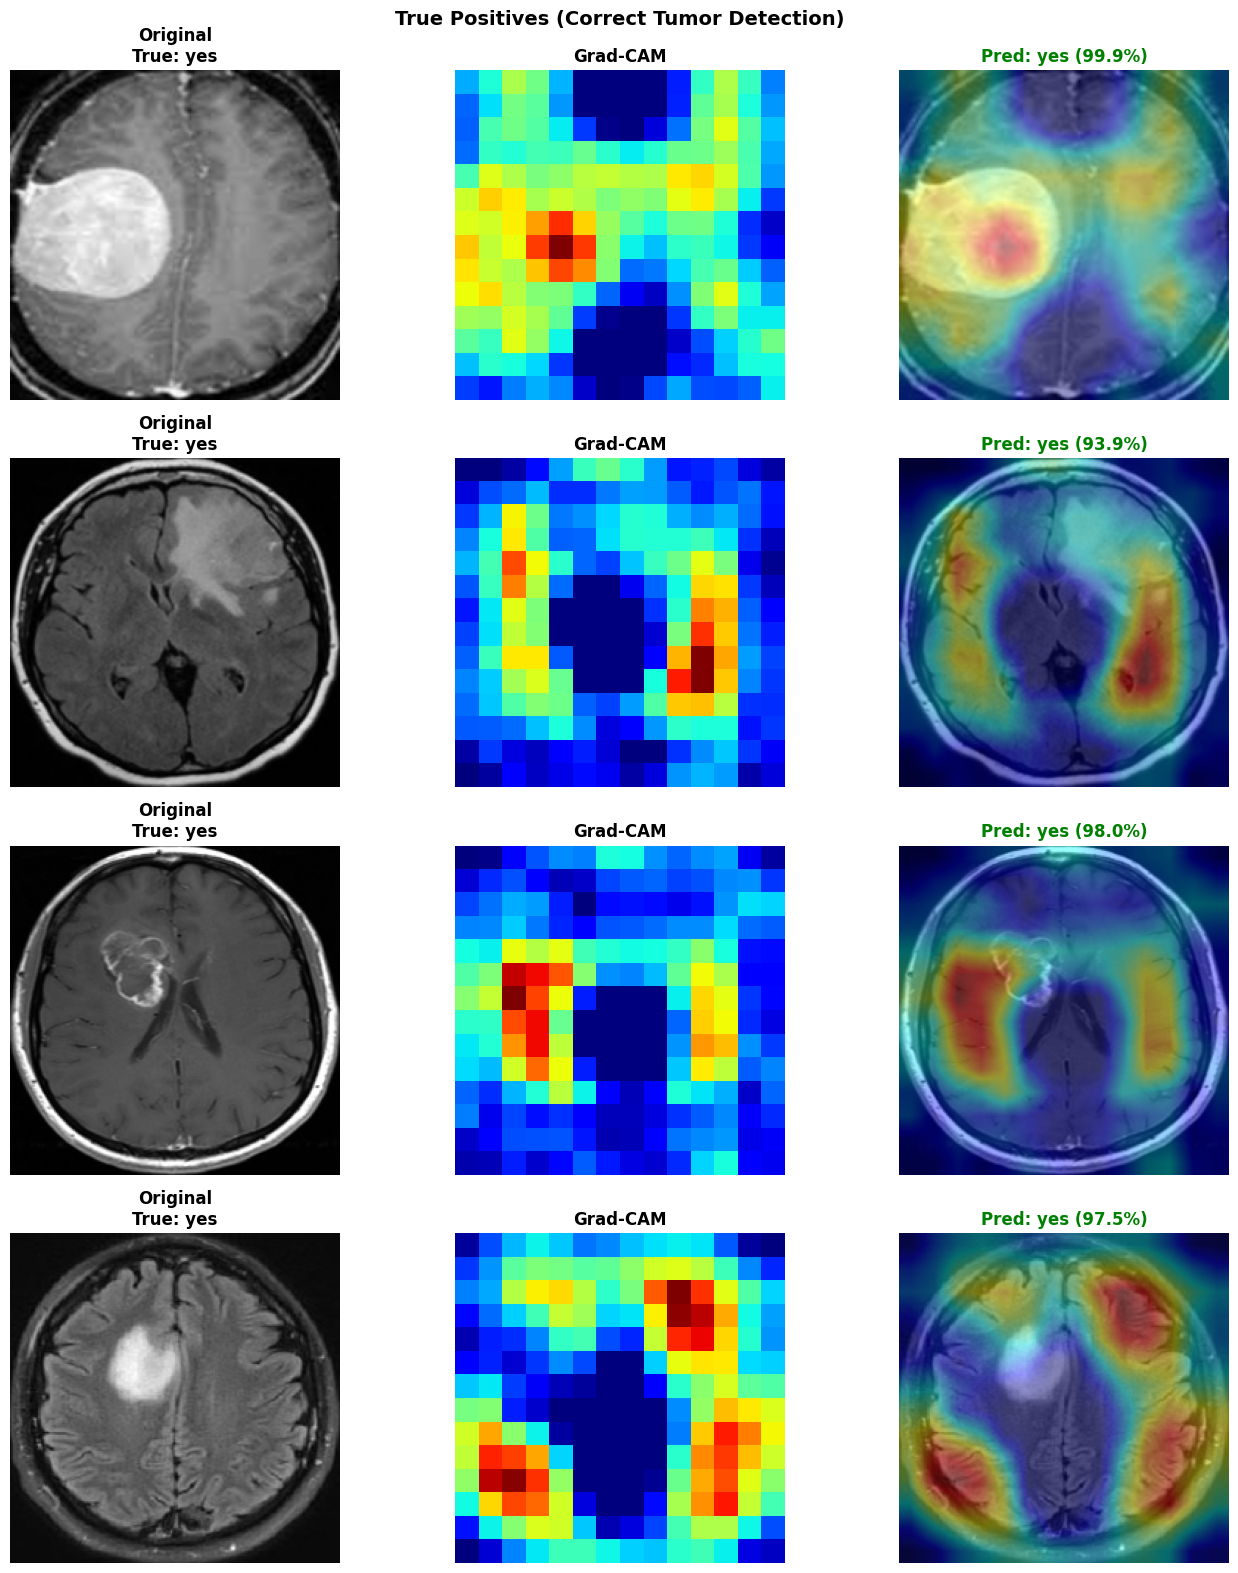

In [ ]:
visualize_gradcam_group(tp_idxs, "True Positives (Correct Tumor Detection)")
visualize_gradcam_group(fp_idxs, " False Positives (Healthy -Tumor)")

-  The model can identify tumor prensence with focus on stuctural abnormalities and intensity differences but not define/ locate exact tumor boundaries
- The model is suitable for classification but not for detailed tumor boundary detection.
-